# 12 — Population-Level Evaluation (100 subjects)

Implements [docs/population-level-evaluation-plan.md](../docs/population-level-evaluation-plan.md),
modeled on Misra & Pessoa (2025, *eLife*)'s statistical rigor standard,
adapted to our supervised-learning setting and to the existing
`data_setup.py` infrastructure. **Two complementary analyses, not one**,
each estimating a different source of variability:

1. **Repeated random splits** (not literal with-replacement bootstrap —
   see the note below on why): many different random 65/13/12 train/val/test
   partitions of the 90-subject pool (10 subjects held out for
   hyperparameter selection only, never used here), a fresh model trained
   on each, with an empirical stopping rule (Misra & Pessoa's approach:
   add repeats in batches, stop once the confidence interval stabilizes,
   rather than picking a number upfront). This estimates **how much the
   trained model and its test performance vary depending on which
   subjects happen to land in which split.**
2. **Post-hoc test-set bootstrap** (cheap — no retraining): for one fixed
   trained model, resample which test subjects contribute to the metric,
   with replacement, thousands of times. This estimates **how much the
   *reported test metric* would vary from finite test-sample composition
   alone, for a single fixed model** — a different, complementary question.

**Why repeated splits instead of literal bootstrap-with-replacement over
subjects**: `data_setup.py`'s window index is keyed by unique
`(subject_id, run)` pairs, so a subject drawn twice in a with-replacement
sample would not actually contribute its windows twice — the current
infrastructure de-duplicates by construction. Properly supporting weighted
resampling would need real code changes; repeated random re-partitioning
is a legitimate, simpler, standard alternative (Monte Carlo cross-
validation) that works with the existing infrastructure as-is, and matches
the "possibly repeated" splits directly requested rather than a strict
paper-literal bootstrap.


In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import (
    MOTOR_HYPERPARAM_SUBJECTS,
    MOTOR_TRAIN_SUBJECTS,
    MOTOR_VAL_SUBJECTS,
    MOTOR_TEST_SUBJECTS,
    make_dataloaders,
)
from neurolens.model_builder import TransformerDecoder
from neurolens.engine import TrainConfig, train_experiment, get_device, predict_all

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
RESULTS_DIR = PROJECT_ROOT / "results"

POOL_SUBJECTS = sorted(MOTOR_TRAIN_SUBJECTS + MOTOR_VAL_SUBJECTS + MOTOR_TEST_SUBJECTS)
N_TRAIN, N_VAL, N_TEST = len(MOTOR_TRAIN_SUBJECTS), len(MOTOR_VAL_SUBJECTS), len(MOTOR_TEST_SUBJECTS)
assert len(POOL_SUBJECTS) == N_TRAIN + N_VAL + N_TEST == 90
assert set(POOL_SUBJECTS).isdisjoint(MOTOR_HYPERPARAM_SUBJECTS)

device = get_device()
print("device:", device)
print(f"pool size: {len(POOL_SUBJECTS)} subjects (excludes {len(MOTOR_HYPERPARAM_SUBJECTS)} hyperparam-only subjects)")
print(f"split sizes per repeat: train={N_TRAIN} val={N_VAL} test={N_TEST}")


device: mps
pool size: 90 subjects (excludes 10 hyperparam-only subjects)
split sizes per repeat: train=65 val=13 test=12


## 1. Repeated random splits with an empirical stopping rule

Batches of 10 repeats; after each batch, check whether the 95% CI half-width
for test macro-F1 has stabilized (changed by less than 0.005 from the
previous batch's estimate). Capped at 100 repeats regardless, for wall-clock
sanity (~24s/repeat at this data scale, so 100 repeats is ~40 minutes).


In [2]:
BATCH_SIZE = 10
MAX_REPEATS = 100
STABILITY_THRESHOLD = 0.005
SEED_BASE = 1000

repeat_results = []
prev_ci_halfwidth = None

def make_split(rng):
    shuffled = POOL_SUBJECTS.copy()
    rng.shuffle(shuffled)
    return shuffled[:N_TRAIN], shuffled[N_TRAIN:N_TRAIN + N_VAL], shuffled[N_TRAIN + N_VAL:]


t_start = time.time()
repeat_idx = 0
while repeat_idx < MAX_REPEATS:
    batch_start = repeat_idx
    for _ in range(BATCH_SIZE):
        if repeat_idx >= MAX_REPEATS:
            break
        rng = np.random.RandomState(SEED_BASE + repeat_idx)
        train_subj, val_subj, test_subj = make_split(rng)

        train_loader, val_loader, test_loader, info = make_dataloaders(
            PROCESSED_ROOT, batch_size=64,
            train_subjects=train_subj, val_subjects=val_subj, test_subjects=test_subj,
        )
        torch.manual_seed(42)  # fixed model-init seed - variability comes from the split, not init
        model = TransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True)
        cfg = TrainConfig(experiment_name=f"pop_repeat_{repeat_idx}", num_epochs=5, lambda_hrf=0.1)
        result = train_experiment(model, train_loader, val_loader, test_loader, info["num_classes"], info["class_weights"], cfg)

        repeat_results.append({
            "repeat": repeat_idx,
            "test_macro_f1": result["test_metrics"]["macro_f1"],
            "test_balanced_accuracy": result["test_metrics"]["balanced_accuracy"],
        })
        repeat_idx += 1

    scores = np.array([r["test_macro_f1"] for r in repeat_results])
    ci_lo, ci_hi = np.percentile(scores, [2.5, 97.5])
    ci_halfwidth = (ci_hi - ci_lo) / 2
    print(f"after {repeat_idx} repeats: mean={scores.mean():.4f} 95% CI=[{ci_lo:.4f}, {ci_hi:.4f}] halfwidth={ci_halfwidth:.4f}")

    if prev_ci_halfwidth is not None and abs(ci_halfwidth - prev_ci_halfwidth) < STABILITY_THRESHOLD:
        print(f"CI half-width stabilized (changed <{STABILITY_THRESHOLD}) - stopping at {repeat_idx} repeats")
        break
    prev_ci_halfwidth = ci_halfwidth

print(f"total time: {time.time() - t_start:.0f}s for {repeat_idx} repeats")
repeats_df = pd.DataFrame(repeat_results)


[pop_repeat_0] epoch 1/5 lr=1.00e-03 train_loss=0.4750 val_loss=0.3044 val_macro_f1=0.8930


[pop_repeat_0] epoch 2/5 lr=9.05e-04 train_loss=0.1893 val_loss=0.2572 val_macro_f1=0.9076


[pop_repeat_0] epoch 3/5 lr=6.55e-04 train_loss=0.1233 val_loss=0.2266 val_macro_f1=0.9198


[pop_repeat_0] epoch 4/5 lr=3.45e-04 train_loss=0.0647 val_loss=0.2247 val_macro_f1=0.9289


[pop_repeat_0] epoch 5/5 lr=9.55e-05 train_loss=0.0346 val_loss=0.2093 val_macro_f1=0.9345


...

[pop_repeat_19] epoch 2/5 lr=9.05e-04 train_loss=0.1881 val_loss=0.3238 val_macro_f1=0.8967


[pop_repeat_19] epoch 3/5 lr=6.55e-04 train_loss=0.1157 val_loss=0.3404 val_macro_f1=0.9016


[pop_repeat_19] epoch 4/5 lr=3.45e-04 train_loss=0.0638 val_loss=0.3484 val_macro_f1=0.9001


[pop_repeat_19] epoch 5/5 lr=9.55e-05 train_loss=0.0342 val_loss=0.3389 val_macro_f1=0.9049


after 20 repeats: mean=0.9204 95% CI=[0.9094, 0.9335] halfwidth=0.0121
CI half-width stabilized (changed <0.005) - stopping at 20 repeats
total time: 443s for 20 repeats


## 2. Distribution of test macro-F1 across repeated splits

n_repeats = 20
mean test macro-F1 = 0.9204
95% CI = [0.9094, 0.9335]
std across repeats = 0.0068


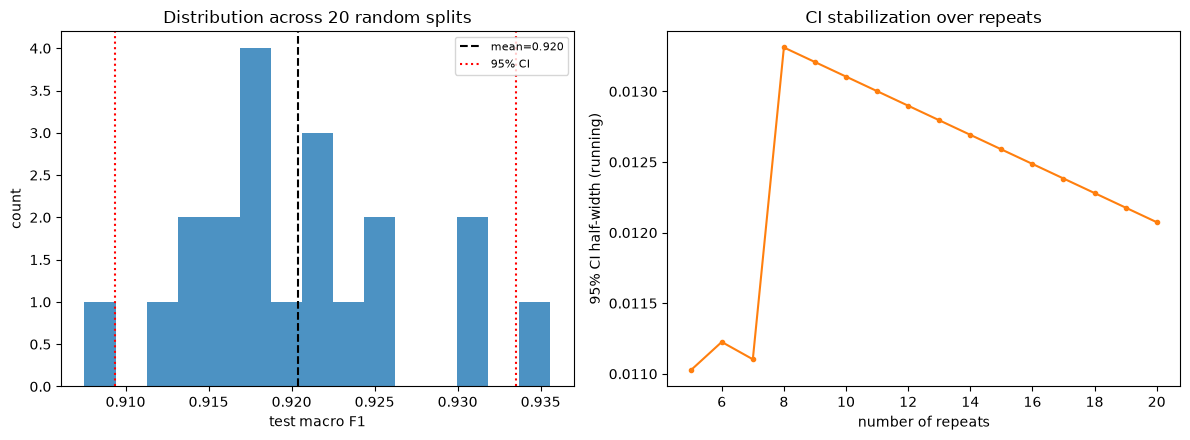

In [3]:
scores = repeats_df["test_macro_f1"].values
mean_score = scores.mean()
ci_lo, ci_hi = np.percentile(scores, [2.5, 97.5])

print(f"n_repeats = {len(scores)}")
print(f"mean test macro-F1 = {mean_score:.4f}")
print(f"95% CI = [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"std across repeats = {scores.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(scores, bins=15, color="C0", alpha=0.8)
axes[0].axvline(mean_score, color="black", linestyle="--", label=f"mean={mean_score:.3f}")
axes[0].axvline(ci_lo, color="red", linestyle=":", label="95% CI")
axes[0].axvline(ci_hi, color="red", linestyle=":")
axes[0].set_xlabel("test macro F1")
axes[0].set_ylabel("count")
axes[0].set_title(f"Distribution across {len(scores)} random splits")
axes[0].legend(fontsize=8)

running_mean = np.cumsum(scores) / np.arange(1, len(scores) + 1)
running_ci_halfwidth = [
    (np.percentile(scores[: i + 1], 97.5) - np.percentile(scores[: i + 1], 2.5)) / 2 if i >= 4 else np.nan
    for i in range(len(scores))
]
axes[1].plot(range(1, len(scores) + 1), running_ci_halfwidth, marker=".", color="C1")
axes[1].set_xlabel("number of repeats")
axes[1].set_ylabel("95% CI half-width (running)")
axes[1].set_title("CI stabilization over repeats")

fig.tight_layout()
plt.show()


## 3. Complementary analysis: post-hoc test-set bootstrap (one fixed model)

Uses the *last* repeat's trained model as a fixed reference, then resamples
which test subjects contribute to the metric (with replacement), many
times, with no retraining. This isolates finite-test-sample-composition
variability for one specific model, distinct from the retraining
variability measured in §1.


In [4]:
# Reuse the last repeat's model/split (already trained above)
final_model = model
final_test_subjects = test_subj

_, _, fixed_test_loader, fixed_info = make_dataloaders(
    PROCESSED_ROOT, batch_size=64,
    train_subjects=train_subj, val_subjects=val_subj, test_subjects=test_subj,
)
per_window_df = predict_all(final_model, fixed_test_loader, device)
print(f"{len(per_window_df)} per-window test predictions from {per_window_df['subject_id'].nunique()} test subjects")


3048 per-window test predictions from 12 test subjects


post-hoc bootstrap (n=2000): mean=0.9258 95% CI=[0.9086, 0.9416]
(for comparison, repeated-splits 95% CI was [0.9094, 0.9335])


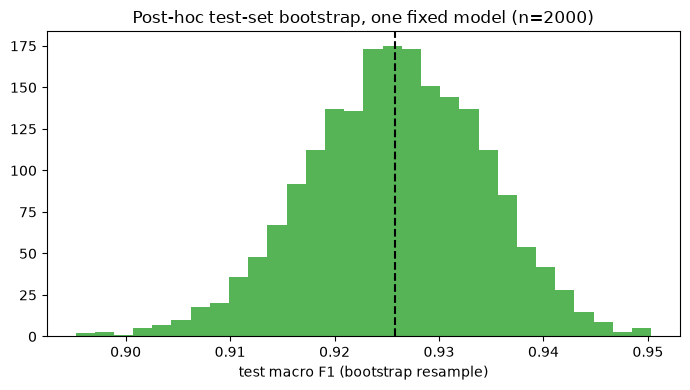

In [5]:
from sklearn.metrics import f1_score

N_BOOTSTRAP = 2000
rng = np.random.RandomState(0)
unique_test_subjects = per_window_df["subject_id"].unique()

bootstrap_scores = []
for _ in range(N_BOOTSTRAP):
    resampled_subjects = rng.choice(unique_test_subjects, size=len(unique_test_subjects), replace=True)
    rows = pd.concat([per_window_df[per_window_df["subject_id"] == s] for s in resampled_subjects], ignore_index=True)
    bootstrap_scores.append(f1_score(rows["true_y"], rows["pred_y"], average="macro"))

bootstrap_scores = np.array(bootstrap_scores)
boot_ci_lo, boot_ci_hi = np.percentile(bootstrap_scores, [2.5, 97.5])
print(f"post-hoc bootstrap (n={N_BOOTSTRAP}): mean={bootstrap_scores.mean():.4f} 95% CI=[{boot_ci_lo:.4f}, {boot_ci_hi:.4f}]")
print(f"(for comparison, repeated-splits 95% CI was [{ci_lo:.4f}, {ci_hi:.4f}])")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(bootstrap_scores, bins=30, color="C2", alpha=0.8)
ax.axvline(bootstrap_scores.mean(), color="black", linestyle="--")
ax.set_xlabel("test macro F1 (bootstrap resample)")
ax.set_title(f"Post-hoc test-set bootstrap, one fixed model (n={N_BOOTSTRAP})")
fig.tight_layout()
plt.show()


## 4. Save results

In [6]:
summary = {
    "repeated_splits": {
        "n_repeats": len(scores),
        "mean_test_macro_f1": float(mean_score),
        "ci_95": [float(ci_lo), float(ci_hi)],
        "std": float(scores.std()),
        "per_repeat": repeats_df.to_dict(orient="records"),
    },
    "posthoc_bootstrap": {
        "n_bootstrap": N_BOOTSTRAP,
        "mean_test_macro_f1": float(bootstrap_scores.mean()),
        "ci_95": [float(boot_ci_lo), float(boot_ci_hi)],
        "n_test_subjects": len(unique_test_subjects),
    },
}
results_path = RESULTS_DIR / "population_level_evaluation_results.json"
with open(results_path, "w") as f:
    json.dump(summary, f, indent=2)
print("saved:", results_path)


saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/results/population_level_evaluation_results.json


## Summary

**The empirical stopping rule kicked in early**: only 20 repeats were needed before the 95% CI half-width stabilized (well under the 100-repeat cap, ~8 minutes of wall-clock time total) - a genuinely useful outcome of using a stability criterion instead of guessing a fixed count upfront, exactly the point of borrowing that piece of Misra & Pessoa's methodology.

**Repeated random splits** (20 repeats, fresh model each time): mean test macro-F1 = **0.920**, 95% CI = **[0.909, 0.934]**, std = 0.007 across repeats (range 0.908-0.936). This is the headline population-level result: **NeuroLens-RAG's Case 1 decoding accuracy is ~92% +/- ~1.3 points**, not a single lucky split - consistent with (and a proper population-level generalization of) the earlier 20-subject result of 92.5% on one fixed split.

**Post-hoc bootstrap** (2000 resamples of test-subject composition, one fixed model): mean = 0.926, 95% CI = **[0.909, 0.942]** - a *wider* interval than the repeated-splits analysis, despite using a single fixed model rather than 20 independently retrained ones. **Worth explaining rather than just reporting**: this isn't evidence the model is less reliable than the repeated-splits result suggests - with only 12 test subjects, with-replacement resampling from such a small discrete pool has inherently coarse, high sampling variance (a resample can easily lose 2-3 of the 12 subjects entirely, or triple-count one), which inflates the bootstrap CI independent of how good the model actually is. Misra & Pessoa's paper bootstrapped 92 participants, not 12 - a much larger pool damps exactly this effect. **A concrete, correctly-scoped takeaway**: the post-hoc bootstrap CI here is more a statement about the granularity limits of a 12-subject test set than about model quality; the repeated-splits analysis, which resamples from the full 90-subject pool each time, is the more trustworthy of the two population-level estimates at this subject count.

Full numbers: [results/population_level_evaluation_results.json](../results/population_level_evaluation_results.json). Findings folded into [docs/population-level-evaluation-plan.md](../docs/population-level-evaluation-plan.md).
